In [129]:
import numpy as np
import matplotlib.pyplot as plt
import math 
import pandas as pd
import random
import simpy as smp

#### source: cs137

In [130]:
meKeV = 511 #[keV]electron mass in kev
na= 6.023e+23 #[atoms/mole], Avogadro number
mmcs = 136.907 #[g/mole], cs137 molar mass
halfLife = 30*365.24*23.93*3600 #[s] half life cs137
decayConstant = np.log(2)/halfLife #[1/s] decay constant
mcs = 1.5e-9 #[g] cs137 mass 
ncs = (mcs*na)/mmcs #[n atomi], number of atoms of cs137 
energyPeak = 661.7  #[keV] cs137 energy peak
A = decayConstant*ncs #[Bq]=[decay/s] activity 

#### environment & $\gamma$ travel

In [131]:
#soil
soilDensity= 1.3 #[g/cm^3]
mac = 0.08045 #[cm^2/g], soil mass attenuation coefficient
absCoefficient = mac*soilDensity#[1/cm], soil linear absorption coefficient

#detector & source
rd = 0.102 #[cm], detector radius
crossSection = rd**2 #[cm^2] detector cross section
csDepth = 0.1 #m, source depth
csHorizontal = 0 #m, average source-detector horizontal distance
csDistance = (csDepth**2 + csHorizontal**2)**0.5 #m average source-detector distance
gammaIntensity = (crossSection*np.exp(-(csDistance*absCoefficient))*A)/(4*np.pi*csDistance**2)
detectionTime = 60 #30min
gammaInteracting = round(gammaIntensity*detectionTime) #gamma entering in the detector in the detection time
channels = 300

#### photoelectric-compton scattering cross section ratio

In [132]:
#toy model: photoelectric-compton scattering cross section ratio at the energy peak
def crossSectionRatio(energy):
    return .5*np.exp(-(1/300)*energy) 
gammaPh = round(gammaInteracting*crossSectionRatio(energyPeak)) #662 keV gamma undergoing photoelectric effect
gammaCompton = round(gammaInteracting-gammaPh) #662 keV gamma undergoing compton effect

#### simulation

In [133]:
c = 299792458.0  #[m/s], speed of light
E = 662000 *1.602176634 * 10**(-19) #[J], incident energy 
h = 6.62607015 * 10**(-34) #[Js], planck constant 
hbar = h / (2 * np.pi) #[Js], reduced planck consant
meKg = 9.1093837015 * 10**(-31) #[kg], electron mass
omega = E / hbar #[1/s], angular frequency
R = hbar * omega / (meKg * c**2) #constant R
g = 1/np.pi #coverage function, uniform on [0, pi]
scatteringAngles = np.linspace(0, np.pi, 1000) #possible scattering angles

class simulation:
    def __init__(self, t, nSamples, gammaEnergy, mu):
        self.t = t #possible scattering angles
        self.nSamples = nSamples #number of gamma doing at least 1 scattering event
        self.gammaEnergy = gammaEnergy #initial energy of the gammas
        #maximum number of scattering envets; the number of scattering events is supposed to be exponentially distributed with mean "mu"
        self.mu = mu 
        phAfterCompton = 0
        
    def I(self, t):#function I(theta)
        return -np.cos(t) / R**2 + \
               np.log(1 + R * (1 - np.cos(t))) * (1/R - 2/R**2 - 2/R**3) - \
               1 / (2 * R * (1 + R * (1 - np.cos(t)))**2) + \
               1 / (1 + R * (1 - np.cos(t))) * (-2/R**2 - 1/R**3)
    
    def omegaPrime(self, t): #angular frequency of the scattered photon
        return omega/(1+(hbar*omega/(meKg*c**2))*(1-np.cos(t)))
    
    def knpdf(self, t): #the klein-nishina pdf
        return (1/(self.I(np.pi)-self.I(0))) * (self.omegaPrime(t)/omega)**2 * (omega/self.omegaPrime(t) + \
                self.omegaPrime(t)/omega -(np.sin(t)**2))*np.sin(t)

    def rejectionSampling(self): #acceptance-rejection method to sample from the klein-nishina pdf
        samples = []
        sample = 0
        M = max(self.knpdf(scatteringAngles))/g 
        while True:
            x = np.random.uniform(0, np.pi)  #uniform sampling [0, pi]
            u = np.random.uniform(0, 1)  #uniform sampling [0, 1]
            if u <= self.knpdf(x) / (M * g): #acceptance-rejection algorithm
                sample = x
                break
        return sample

    def knSamplingPlot(self):
        thetaSamples = []
        for _ in range(self.nSamples):
            thetaSample = self.rejectionSampling()
            thetaSamples.append(thetaSample)
        knpdf = self.knpdf(scatteringAngles) #knpdf computed in the interval [0, pi]
        fig = plt.figure(facecolor=(1,1,1)) 
        plt.hist(thetaSamples, bins=1000, density=True, label='θ sampling', histtype='stepfilled', color='#007be8')
        plt.plot(scatteringAngles, knpdf, label='klein-nishina PDF', color='red', linewidth=2)
        plt.legend()
        plt.xlabel('θ')
        plt.title('compton scattering angles')
        fig.set_figheight(2.5)
        fig.set_figwidth(5)
        plt.grid(linewidth=0.3)
        plt.show()
        plt.close(fig)

    def energyLoss(self, gammaEnergy): #energy lost by a photon in a single scattering event
        return gammaEnergy*(1-(1/(1 + ((gammaEnergy/meKeV) * (1 - np.cos(self.rejectionSampling()))))))

    def resolution(self, energy):
        detResolution = 1.714824*energy**(-0.504)
        FWHM = energyPeak * resolution 
        sigma = FWHM / 2.335
        return sigma
        
    def compton(self):
        scatteringEventsNumber = np.random.exponential(self.mu, self.nSamples).astype(int)+2 #probability of the number of scattering events
        scatteringSteps = []
        deposited = []
        phAfterCompton = 0
        for i in scatteringEventsNumber:
            energyDep = np.zeros(i)
            energyRem = np.zeros(i)
            energyRem[0] = self.gammaEnergy
            for j in range(i-1):
                if crossSectionRatio(energyRem[j+1]) < np.random.uniform(0, 1):
                    energyDep[j] = self.energyLoss(energyRem[j])
                    energyRem[j+1] = energyRem[j] - energyDep[j]
                else:
                    phAfterCompton += 1
                    break                    
            scatteringSteps.append(energyDep)  
        for i in scatteringSteps:
            deposited.append(np.sum(i))
            depositedEnergies = np.array(deposited).astype(int) 
            depositedEnergies = depositedEnergies[depositedEnergies != 0]
        #each final energy deposited is measured with an uncertainty depending on the energy itself:
        for i in depositedEnergies:
            i = np.random.normal(i, self.resolution(i), 1)
        return [depositedEnergies, phAfterCompton]
    
    def photoelectric(self):
        comptonData = self.compton()[1]
        phCounts = np.random.normal(energyPeak, self.resolution(energyPeak), gammaPh+comptonData).astype(int)
        return phCounts
    
    def gammaSpectrum(self):
        gammaSpec = np.concatenate((self.photoelectric(), self.compton()[0]), axis=None)
        energies, counts = np.unique(gammaSpec, return_counts=True)
        fig = plt.figure(facecolor=(1,1,1)) #axis color
        fig.set_figheight(2.5)
        fig.set_figwidth(5)
        plt.plot(energies, counts, color='#007be8', linewidth=1)
        plt.xlabel('energy [keV]')
        plt.ylabel('counts')
        plt.title(r'cs137 $\gamma$ spectrum')
        ax = plt.gca()
        ax.set_yscale('log')
        ax.grid(linewidth=0.3)
        plt.show()
        
    def comptonPlot(self):
        data = simulation.compton()[0]
        fig, ax = plt.subplots(figsize=(4, 2), facecolor=(1,1,1))
        plt.hist(data, bins=10000, label='θ sampling', color='#31A772', histtype='stepfilled', edgecolor='#31A772')
        ax.set_xlabel('energy')
        ax.set_ylabel('counts')
        ax.set_title('compton: energy deposited')
        ax.grid(linewidth=0.3)
        plt.show()

#### running the simulation

In [134]:
simulation = simulation(scatteringAngles, gammaCompton, energyPeak, 3)

#### $\theta$ sampling plot

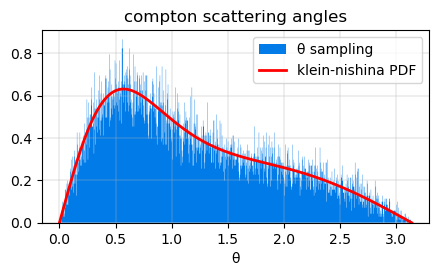

In [135]:
simulation.knSamplingPlot()

#### full gamma spectrum

In [ ]:
simulation.gammaSpectrum()